# Gira - Bicicletas de Lisboa

# Analysis

In [2]:
# ── Imports ─────────────────────────────────────────────
import pandas as pd                          # tables, grouping, all aggregation
import numpy as np                           # vectorised maths: np.select, np.polyfit, trig
import matplotlib.pyplot as plt              # every static chart in the notebook
import matplotlib.dates as mdates            # date ticks on the monthly time axis
import seaborn as sns                        # heatmaps and the shared chart theme
import requests, time                        # calling the elevation API, pausing between calls
import importlib
!pip install folium
import folium                                # interactive Leaflet map of the network
from branca.colormap import LinearColormap   # continuous colour scale for that map

# Display / plotting defaults, set once so every cell below inherits them
pd.set_option('display.max_columns', None)   # never hide columns when printing a frame
pd.set_option('display.width', 120)          # wider output before pandas wraps lines
sns.set_theme(style="whitegrid")             # consistent look across all figures
plt.rcParams['figure.dpi'] = 110             # sharper output for the slide deck

In [3]:
# ── Load the cleaned dataset ────────────────────────────
# Parquet, not CSV: it keeps dtypes (categoricals, booleans, tz-aware timestamps)
# and loads in seconds instead of minutes. The cleaning notebook is the only thing
# that writes this file; nothing here modifies it.
gira = pd.read_parquet('gira_clean.parquet')

print("Shape:", gira.shape)          # expect (4090179, 23)
print("\nColumns:", list(gira.columns))
print("\nMemory:", f"{gira.memory_usage(deep=True).sum()/1e6:.0f} MB")
gira.head(3)                         # eyeball the first rows to confirm the load

Shape: (4090179, 23)

Columns: ['desigcomercial', 'numbicicletas', 'numdocasvacias', 'entity_ts', 'station_id', 'numdocas', 'estado', 'ts_local', 'numdocasvacias_fix', 'is_impossible', 'is_repair', 'lon', 'lat', 'occupancy_rate', 'is_empty', 'is_full', 'year', 'quarter', 'month', 'date', 'hour', 'weekday', 'period']

Memory: 681 MB


,desigcomercial,numbicicletas,numdocasvacias,entity_ts,station_id,numdocas,estado,ts_local,numdocasvacias_fix,is_impossible,is_repair,lon,lat,occupancy_rate,is_empty,is_full,year,quarter,month,date,hour,weekday,period
0,208 - Cais das Pombas,0,22,2020-01-01 00:04:01,208,22,NaN,2020-01-01 00:04:01+00:00,22,False,False,-9.14373,38.70523,0.0,True,False,2020,1,1,2020-01-01,0,2,Pre-COVID
1,446 - Av. República / Interface Entrecampos,32,8,2020-01-01 00:04:01,446,40,NaN,2020-01-01 00:04:01+00:00,8,False,False,-9.14773,38.74456,0.8,False,False,2020,1,1,2020-01-01,0,2,Pre-COVID
2,301 - Avenida da Liberdade / Restauradores,22,0,2020-01-01 00:04:01,301,22,NaN,2020-01-01 00:04:01+00:00,0,False,False,-9.14242,38.71702,1.0,False,True,2020,1,1,2020-01-01,0,2,Pre-COVID


## Step 1 - exclude repair and impossible rows

In [4]:
# Analysis base: only rows where a failure is actually measurable.
# .copy() so the later `is_weekend` assignment writes to this frame and never
# back to `gira`, which stays exactly as the cleaning notebook produced it.
base = gira[~gira['is_repair'] & ~gira['is_impossible']].copy()

# How much was removed, and by which flag
print(f"kept:       {len(base):,} of {len(gira):,} ({len(base)/len(gira)*100:.2f}%)")
print(f"repair:     {gira['is_repair'].sum():,}")
print(f"impossible: {gira['is_impossible'].sum():,}")
print()

# Side-by-side proof that the filter matters: the same rate on both populations.
# The gap is the dilution caused by leaving unusable snapshots in the denominator.
print(f"empty rate — full frame: {gira['is_empty'].mean()*100:.2f}%"
      f"   |   base: {base['is_empty'].mean()*100:.2f}%")
print(f"full rate  — full frame: {gira['is_full'].mean()*100:.2f}%"
      f"   |   base: {base['is_full'].mean()*100:.2f}%")

kept:       3,929,859 of 4,090,179 (96.08%)
repair:     160,208
impossible: 20,976

empty rate — full frame: 5.04%   |   base: 5.24%
full rate  — full frame: 1.96%   |   base: 2.04%


### Does the filter bias the year-on-year story?

In [5]:
# Per-year impact of the analysis mask. Self-contained: the mask is rebuilt here
# from the same two flags used to build `base`, so nothing depends on kernel state.
keep = ~gira['is_repair'] & ~gira['is_impossible']

# `year` is a nullable dtype and is <NA> for the rows that fall in the DST clock-change
# gap, where the timestamp is NaT by design. Sorting those raises "boolean value of NA
# is ambiguous", so drop them first and report them rather than letting them vanish.
n_no_year = gira['year'].isna().sum()
years = sorted(int(y) for y in gira['year'].dropna().unique())
print(f"Years found: {years}   (rows with no year, DST gap: {n_no_year:,})\n")

# One row per year: size before and after the mask, plus the rates on each population
rows = []
for y in years:
    g_all  = gira[gira['year'] == y]                 # every snapshot logged that year
    g_base = g_all[keep.loc[g_all.index]]            # the subset that survives the mask
    rows.append({
        'year': int(y),
        'n_raw': len(g_all),
        'n_base': len(g_base),
        'pct_dropped': (1 - len(g_base) / len(g_all)) * 100,
        'empty_before': g_all['is_empty'].mean() * 100,   # rate with unusable rows included
        'empty_after':  g_base['is_empty'].mean() * 100,  # rate on the analysis base
        'full_before':  g_all['is_full'].mean() * 100,
        'full_after':   g_base['is_full'].mean() * 100,
    })

impact = pd.DataFrame(rows)
# The shift columns are the actual answer: small and similar across years = no bias
impact['empty_shift'] = impact['empty_after'] - impact['empty_before']
impact['full_shift']  = impact['full_after']  - impact['full_before']
print(impact.round(2).to_string(index=False))

# Sanity check on the interpretation: the excluded rows are not silently full of
# failures. is_empty / is_full are already False for them by construction, so both
# rates must read 0.00% — if they do not, the cleaning flags disagree with themselves.
excl = gira[~keep]
print(f"\nExcluded rows: {len(excl):,}")
print(f"Excluded rows — empty rate: {excl['is_empty'].mean()*100:.3f}%")
print(f"Excluded rows — full rate:  {excl['is_full'].mean()*100:.3f}%")
print(f"Excluded rows — median bikes present: {excl['numbicicletas'].median()}")

Years found: [2020, 2021, 2022, 2023]   (rows with no year, DST gap: 146)

 year   n_raw  n_base  pct_dropped  empty_before  empty_after  full_before  full_after  empty_shift  full_shift
 2020  398163  398153         0.00          3.86         3.86         1.76        1.76         0.00        0.00
 2021 1232857 1226155         0.54          5.40         5.43         2.10        2.11         0.03        0.01
 2022 1852486 1735608         6.31          5.47         5.84         1.98        2.11         0.37        0.13
 2023  606527  569797         6.06          3.74         3.98         1.75        1.87         0.24        0.11

Excluded rows: 160,320
Excluded rows — empty rate: 0.000%
Excluded rows — full rate:  0.000%
Excluded rows — median bikes present: 0.0


## Step 2 - network growth

In [6]:
# Network growth uses a DIFFERENT filter from `base` on purpose: a station under
# repair still physically exists and still has docks, so repair rows must stay in
# when counting stations and capacity. Only physically impossible rows are dropped.
net = gira[~gira['is_impossible']]

# 1) active stations per year — DISTINCT count, not row count
#    (nunique, because each station appears in tens of thousands of snapshots)
stations_per_year = net.groupby('year')['station_id'].nunique()

# 2) total capacity per year: ONE representative capacity per station, then summed.
#    Never sum numdocas over all rows — that multiplies capacity by logging frequency.
#    Median per station absorbs the odd mis-logged snapshot; the sum is the fleet size.
cap_per_station   = net.groupby(['year', 'station_id'])['numdocas'].median()
capacity_per_year = cap_per_station.groupby('year').sum()

# Join the two series into one small table, one row per year
growth = pd.DataFrame({
    'stations': stations_per_year,
    'capacity': capacity_per_year.astype(int)
})
print(growth)

      stations  capacity
year                    
2020        85      1568
2021       102      1915
2022       146      2887
2023       147      2928


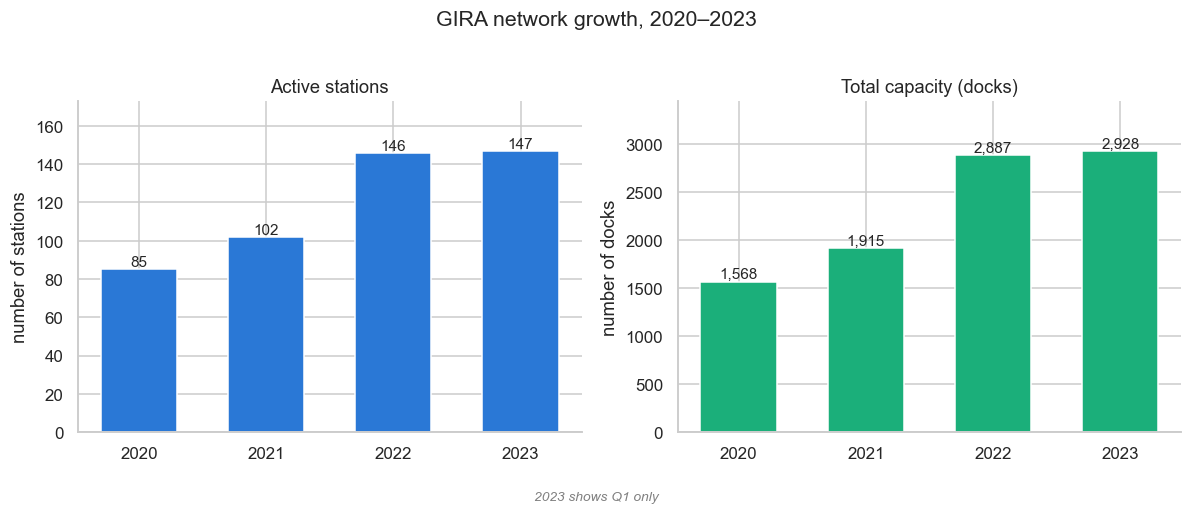

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))   # two panels side by side

years = growth.index.astype(str)   # years as strings so they plot as categories, not numbers

# Panel 1 — stations
axes[0].bar(years, growth['stations'], color='#2a78d6', width=0.6)
axes[0].set_title('Active stations', fontsize=12, weight='medium')
axes[0].set_ylabel('number of stations')
for i, v in enumerate(growth['stations']):        # value label above each bar
    axes[0].text(i, v + 1.5, str(v), ha='center', fontsize=10)

# Panel 2 — capacity
axes[1].bar(years, growth['capacity'], color='#1baf7a', width=0.6)
axes[1].set_title('Total capacity (docks)', fontsize=12, weight='medium')
axes[1].set_ylabel('number of docks')
for i, v in enumerate(growth['capacity']):        # same, with thousands separator
    axes[1].text(i, v + 30, f"{v:,}", ha='center', fontsize=10)

fig.suptitle('GIRA network growth, 2020–2023', fontsize=14, weight='medium', y=1.02)
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)   # drop the box, keep it clean
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)   # headroom for labels

# The caveat belongs on the chart, not only in the speech: 2023 is a partial year
fig.text(0.5, -0.04, '2023 shows Q1 only', ha='center', fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.show()

## Step 3 - when do failures happen?

In [8]:
# Failure rate by hour of day — the mean of a boolean IS the rate.
# Computed on `base`, so repair/impossible snapshots are out of the denominator too.
# observed=True stops pandas expanding unused categorical combinations.
hourly = base.groupby('hour', observed=True).agg(
    empty_rate=('is_empty', 'mean'),     # share of snapshots with no bike
    full_rate=('is_full', 'mean'),       # share of snapshots with no free dock
    n=('is_empty', 'size')               # snapshots behind each hour, to judge reliability
).reset_index()

hourly['empty_rate'] *= 100   # to percentages
hourly['full_rate']  *= 100
print(hourly.round(2))

    hour  empty_rate  full_rate       n
0      0        4.69       3.23  165635
1      1        4.73       3.35  164709
2      2        4.51       3.56  162982
3      3        4.11       3.68  165334
4      4        4.07       3.74  165255
5      5        3.91       3.43  166718
6      6        4.04       2.96  158357
7      7        3.82       1.90  166443
8      8        4.72       1.22  164774
9      9        6.05       1.17  165806
10    10        6.75       1.38  166673
11    11        6.83       1.12  162400
12    12        6.49       0.94  161564
13    13        6.21       0.91  162815
14    14        5.67       1.04  161229
15    15        6.02       1.01  161112
16    16        6.34       0.96  162651
17    17        6.26       1.01  162105
18    18        6.17       1.09  163270
19    19        5.52       1.43  164023
20    20        5.02       1.93  163061
21    21        4.57       2.33  164444
22    22        4.63       2.46  165131
23    23        4.77       2.98  163222


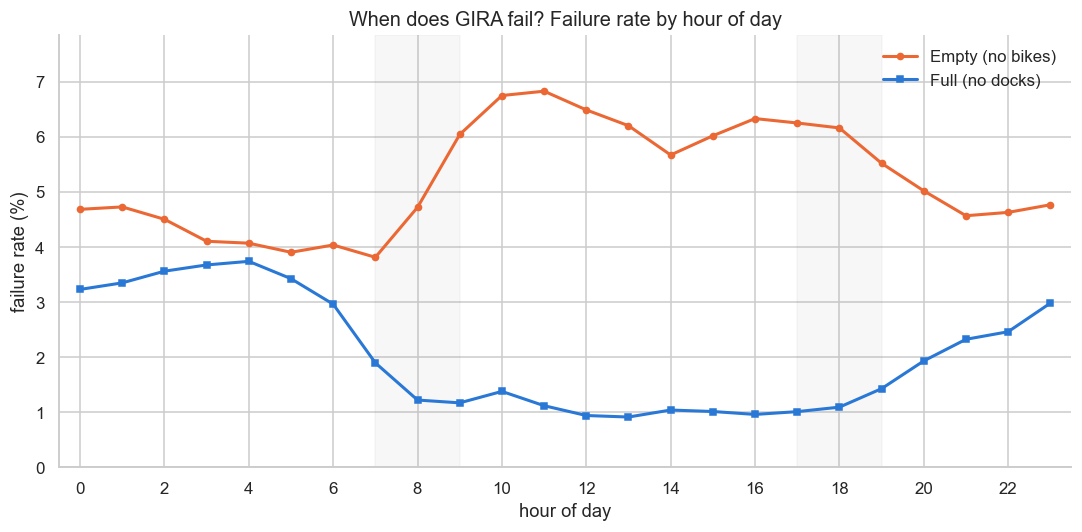

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

# Two lines, one per failure direction, so the shapes can be compared at a glance
ax.plot(hourly['hour'], hourly['empty_rate'], color='#eb6834', linewidth=2,
        marker='o', markersize=4, label='Empty (no bikes)')
ax.plot(hourly['hour'], hourly['full_rate'], color='#2a78d6', linewidth=2,
        marker='s', markersize=4, label='Full (no docks)')

ax.set_xlabel('hour of day')
ax.set_ylabel('failure rate (%)')
ax.set_title('When does GIRA fail? Failure rate by hour of day',
             fontsize=13, weight='medium')
ax.set_xticks(range(0, 24, 2))     # a tick every two hours keeps the axis readable
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, hourly[['empty_rate','full_rate']].max().max() * 1.15)  # 15% headroom

# mark the commute windows lightly
ax.axvspan(7, 9,  alpha=0.06, color='gray')     # morning peak
ax.axvspan(17, 19, alpha=0.06, color='gray')    # evening peak

ax.legend(frameon=False, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## Step 4 - split by weekday vs weekend

In [10]:
# weekday = Mon–Fri (0–4), weekend = Sat–Sun (5–6)
# Written to `base` (a copy), so the original `gira` frame is never touched.
base['is_weekend'] = base['weekday'] >= 5

# Same hourly rates as above, but split into two curves by day type
hourly_split = (base.groupby(['is_weekend', 'hour'], observed=True)
                    .agg(empty_rate=('is_empty', 'mean'),
                         full_rate=('is_full', 'mean'),
                         n=('is_empty', 'size'))
                    .reset_index())
hourly_split[['empty_rate','full_rate']] *= 100

# pivot for easy plotting
wk = hourly_split[~hourly_split['is_weekend']]    # weekdays
we = hourly_split[ hourly_split['is_weekend']]    # weekends

# idxmax gives the row of the worst hour; the gap between the two is the finding
print("Weekday empty peak:", wk.loc[wk['empty_rate'].idxmax(), ['hour','empty_rate']].tolist())
print("Weekend empty peak:", we.loc[we['empty_rate'].idxmax(), ['hour','empty_rate']].tolist())
print("\nWeekday empty range:", round(wk['empty_rate'].min(),1), "–", round(wk['empty_rate'].max(),1))
print("Weekend empty range:", round(we['empty_rate'].min(),1), "–", round(we['empty_rate'].max(),1))

Weekday empty peak: [np.int8(10), np.float64(7.748913390055212)]
Weekend empty peak: [np.int8(16), np.float64(7.020590943333055)]

Weekday empty range: 3.9 – 7.7
Weekend empty range: 3.4 – 7.0


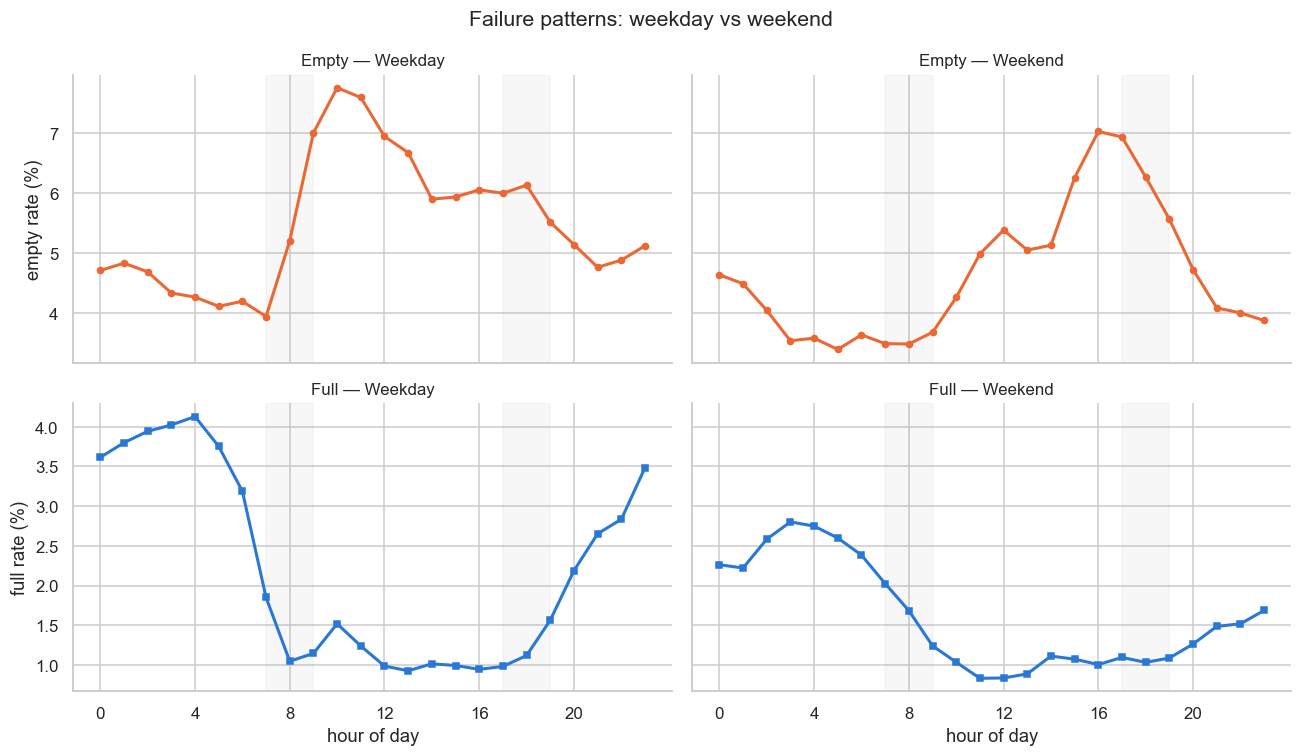

In [11]:
# 2x2 grid: rows = failure type, columns = day type.
# sharey='row' puts both panels of a row on the same scale, so weekday and weekend
# are visually comparable; sharex aligns all four on the same 24-hour axis.
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey='row')

# One helper instead of four near-identical blocks
def panel(ax, data, col, color, marker, title):
    ax.plot(data['hour'], data[col], color=color, lw=2, marker=marker, ms=4)
    ax.set_title(title, fontsize=11, weight='medium')
    ax.axvspan(7, 9, alpha=0.06, color='gray')      # commute shading, as above
    ax.axvspan(17, 19, alpha=0.06, color='gray')
    ax.spines[['top','right']].set_visible(False)
    ax.set_xticks(range(0, 24, 4))

panel(axes[0,0], wk, 'empty_rate', '#eb6834', 'o', 'Empty — Weekday')
panel(axes[0,1], we, 'empty_rate', '#eb6834', 'o', 'Empty — Weekend')
panel(axes[1,0], wk, 'full_rate',  '#2a78d6', 's', 'Full — Weekday')
panel(axes[1,1], we, 'full_rate',  '#2a78d6', 's', 'Full — Weekend')

# Labels only on the outer edges, since the axes are shared
axes[0,0].set_ylabel('empty rate (%)')
axes[1,0].set_ylabel('full rate (%)')
for ax in axes[1,:]:
    ax.set_xlabel('hour of day')

fig.suptitle('Failure patterns: weekday vs weekend', fontsize=14, weight='medium', y=0.98)
plt.tight_layout()
plt.show()

## Step 5 - Availability during lockdown

In [12]:
# Failure rate mensal, 2020–2023 (sobre `base`: sem linhas repair/impossible)
# Uma linha por par ano-mês, para ver a tendência ao longo dos três anos.
monthly = base.groupby(['year', 'month'], observed=True).agg(
    empty_rate=('is_empty', 'mean'),
    full_rate=('is_full', 'mean'),
    n=('is_empty', 'size')
).reset_index()

monthly['empty_rate']   *= 100
monthly['full_rate']    *= 100
# Falha total = as duas direções somadas (são mutuamente exclusivas por definição)
monthly['failure_rate']  = monthly['empty_rate'] + monthly['full_rate']

# Eixo x como data (dia 1 de cada mês)
# Sem isto, ano e mês seriam categorias e os intervalos ficariam distorcidos.
monthly['year_month'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' + monthly['month'].astype(str) + '-01'
)
monthly = monthly.sort_values('year_month').reset_index(drop=True)

# Janela de lockdown derivada da coluna `period` — fonte única de verdade,
# em vez de datas escritas à mão que podem divergir da limpeza.
lock_ts = gira.loc[gira['period'] == 'Lockdown', 'ts_local']
lockdown_start = lock_ts.min().tz_localize(None)   # tz removida para comparar com year_month
lockdown_end   = lock_ts.max().tz_localize(None)
print(f"Janela de lockdown derivada de `period`: "
      f"{lockdown_start:%d-%m-%Y} a {lockdown_end:%d-%m-%Y}\n")

print(monthly[['year', 'month', 'empty_rate', 'full_rate', 'failure_rate', 'n']].round(2))

Janela de lockdown derivada de `period`: 18-03-2020 a 03-05-2020

    year  month  empty_rate  full_rate  failure_rate       n
0   2020      1        1.66       2.15          3.82   33408
1   2020      2        2.05       2.43          4.49   30412
2   2020      3        3.61       4.05          7.66   35567
3   2020      4        0.68       0.66          1.34   46795
4   2020      5        0.93       1.55          2.48   25808
5   2020      6        2.05       0.88          2.93   28263
6   2020      7        3.96       1.84          5.79   34137
7   2020      8        3.48       1.76          5.24   36840
8   2020      9        6.17       2.27          8.44   27017
9   2020     10        7.22       1.62          8.84   57302
10  2020     11        8.06       0.91          8.97   23377
11  2020     12        7.51       0.68          8.19   19227
12  2021      1        4.35       0.76          5.11   40656
13  2021      2        5.40       0.38          5.79   76981
14  2021      3    

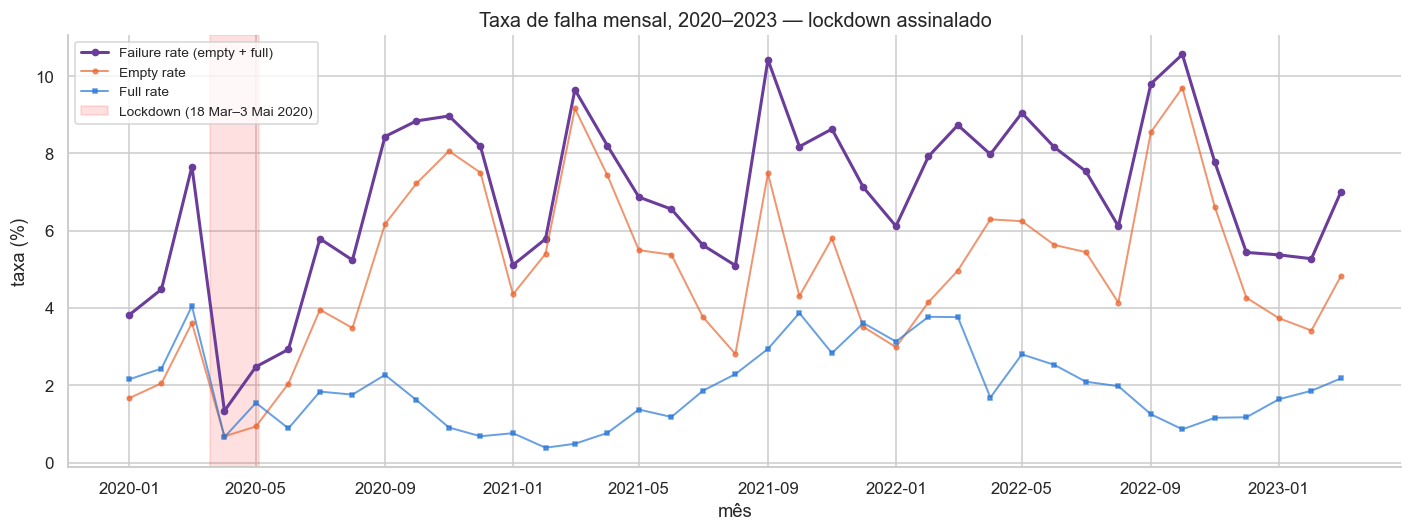

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

# Linha grossa = falha total; as duas finas mostram de onde vem cada movimento
ax.plot(monthly['year_month'], monthly['failure_rate'], color='#6a3d9a', lw=2,
        marker='o', ms=4, label='Failure rate (empty + full)')
ax.plot(monthly['year_month'], monthly['empty_rate'], color='#eb6834', lw=1.3,
        marker='o', ms=3, alpha=0.7, label='Empty rate')
ax.plot(monthly['year_month'], monthly['full_rate'], color='#2a78d6', lw=1.3,
        marker='s', ms=3, alpha=0.7, label='Full rate')

# lockdown_start / lockdown_end vêm da célula anterior, derivados de `period`
# O rótulo é construído a partir dessas datas, para nunca contradizer a faixa desenhada.
meses = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
         7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
rotulo = (f"Lockdown ({lockdown_start.day} {meses[lockdown_start.month]}–"
          f"{lockdown_end.day} {meses[lockdown_end.month]} {lockdown_end.year})")
ax.axvspan(lockdown_start, lockdown_end, color='red', alpha=0.12, label=rotulo)

ax.set_xlabel('mês')
ax.set_ylabel('taxa (%)')
ax.set_title('Taxa de falha mensal, 2020–2023 — lockdown assinalado',
             fontsize=13, weight='medium')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## Step 6 - the geography question

In [14]:
# Per-station failure profile, on `base` (repair + impossible excluded from the denominator).
# One row per station: identity, position, size, and both failure rates.
station = (base.groupby('station_id', observed=True)
           .agg(name=('desigcomercial', 'first'),   # name is constant per station
                lat=('lat', 'median'),              # median absorbs GPS jitter between logs
                lon=('lon', 'median'),
                capacity=('numdocas', 'median'),    # representative dock count
                n_obs=('is_empty', 'size'),         # how much evidence this station has
                empty_rate=('is_empty', 'mean'),
                full_rate=('is_full', 'mean'),
                occupancy=('occupancy_rate', 'mean'))
           .reset_index())

station['empty_rate'] *= 100
station['full_rate']  *= 100
station['total_fail'] = station['empty_rate'] + station['full_rate']   # overall severity

# net tilt: positive = empty-prone, negative = full-prone
# One number per station saying which way it leans, used for the maps and correlations.
station['tilt'] = station['empty_rate'] - station['full_rate']

# A rate built on a handful of snapshots is noise, not a finding: a station seen once
# while empty scores 100%. Flag the thin ones and keep them out of every ranking.
MIN_OBS = 1000
station['reliable'] = station['n_obs'] >= MIN_OBS

# Three-way classification, as the brief asks. A station is "balanced" when neither
# failure clearly dominates — the minority type is still more than a third of its
# failures. Threshold stated explicitly so it can be defended (or changed) on the day.
share_empty = station['empty_rate'] / station['total_fail'].replace(0, np.nan)  # 0 -> NaN avoids /0
station['failure_type'] = np.select(
    [share_empty >= 0.65, share_empty <= 0.35],   # conditions, tested in order
    ['empty-risk', 'full-risk'],                  # matching labels
    default='balanced')                           # anything in between

# kept for backwards compatibility with the cells below
station['dominant'] = np.where(station['empty_rate'] > station['full_rate'], 'empty', 'full')

rel = station[station['reliable']]   # the only subset used for any ranking or claim

print(f"Stations profiled: {len(station)}")
print(f"Reliable (>= {MIN_OBS:,} snapshots): {len(rel)}   "
      f"dropped as too thin: {(~station['reliable']).sum()}")
print(f"\nObservation counts among reliable stations — min: {rel['n_obs'].min():,}, "
      f"median: {rel['n_obs'].median():,.0f}, max: {rel['n_obs'].max():,}")

print("\nThree-way failure type split (reliable stations only):")
print(rel['failure_type'].value_counts().to_string())
print("\nTwo-way split (which is merely larger):")
print(rel['dominant'].value_counts().to_string())

print("\nMost empty-prone stations:")
print(rel.nlargest(5, 'empty_rate')[['station_id','name','empty_rate','full_rate','n_obs']].to_string(index=False))
print("\nMost full-prone stations:")
print(rel.nlargest(5, 'full_rate')[['station_id','name','empty_rate','full_rate','n_obs']].to_string(index=False))

# Show what the reliability filter caught, so the exclusion is auditable rather than silent
if (~station['reliable']).any():
    print(f"\nExcluded as too thin (would otherwise top the ranking on noise):")
    print(station[~station['reliable']]
          .nlargest(5, 'empty_rate')[['station_id','name','empty_rate','n_obs']].to_string(index=False))

Stations profiled: 147
Reliable (>= 1,000 snapshots): 141   dropped as too thin: 6

Observation counts among reliable stations — min: 3,463, median: 35,535, max: 38,730

Three-way failure type split (reliable stations only):
failure_type
empty-risk    91
balanced      37
full-risk     13

Two-way split (which is merely larger):
dominant
empty    107
full      34

Most empty-prone stations:
 station_id                                                     name  empty_rate  full_rate  n_obs
        479                     479 - Rua Professor Oliveira Marques   21.887326   0.424202  26874
        407                            407 - Praça Duque de Saldanha   19.904392   0.254396  35771
        364       364 -Rua D.francisco M. de melo / Rua artilharia 1   19.166106   0.115285  10409
        412 412 - Av. Ressano Garcia / Av. António Augusto de Aguiar   18.108804   0.738792  35734
        314           314 - Rua Marques da Silva / Rua António Pedro   16.253623   5.778672  16907

Most full-pr

In [15]:
prof = station[station['reliable']].copy()   # trustworthy stations only

# Latitude is the cheap proxy for "further north = further uphill" in Lisbon.
# Test it first, so the real elevation data later has something to be compared against.
print("Median latitude by dominant failure type:")
print(prof.groupby('dominant')['lat'].median())

# tilt > 0 = empty-prone; if hills hold, higher lat -> more empty -> positive corr
corr_lat = prof['tilt'].corr(prof['lat'])   # stored so the elevation cell quotes the real value
print(f"\nCorrelation (tilt vs latitude): {corr_lat:.3f}")

# Same test read as two medians rather than one coefficient
print("\nEmpty-prone stations — median lat:", round(prof[prof['dominant']=='empty']['lat'].median(), 4))
print("Full-prone stations  — median lat:", round(prof[prof['dominant']=='full']['lat'].median(), 4))

Median latitude by dominant failure type:
dominant
empty    38.746836
full     38.739155
Name: lat, dtype: float64

Correlation (tilt vs latitude): 0.061

Empty-prone stations — median lat: 38.7468
Full-prone stations  — median lat: 38.7392


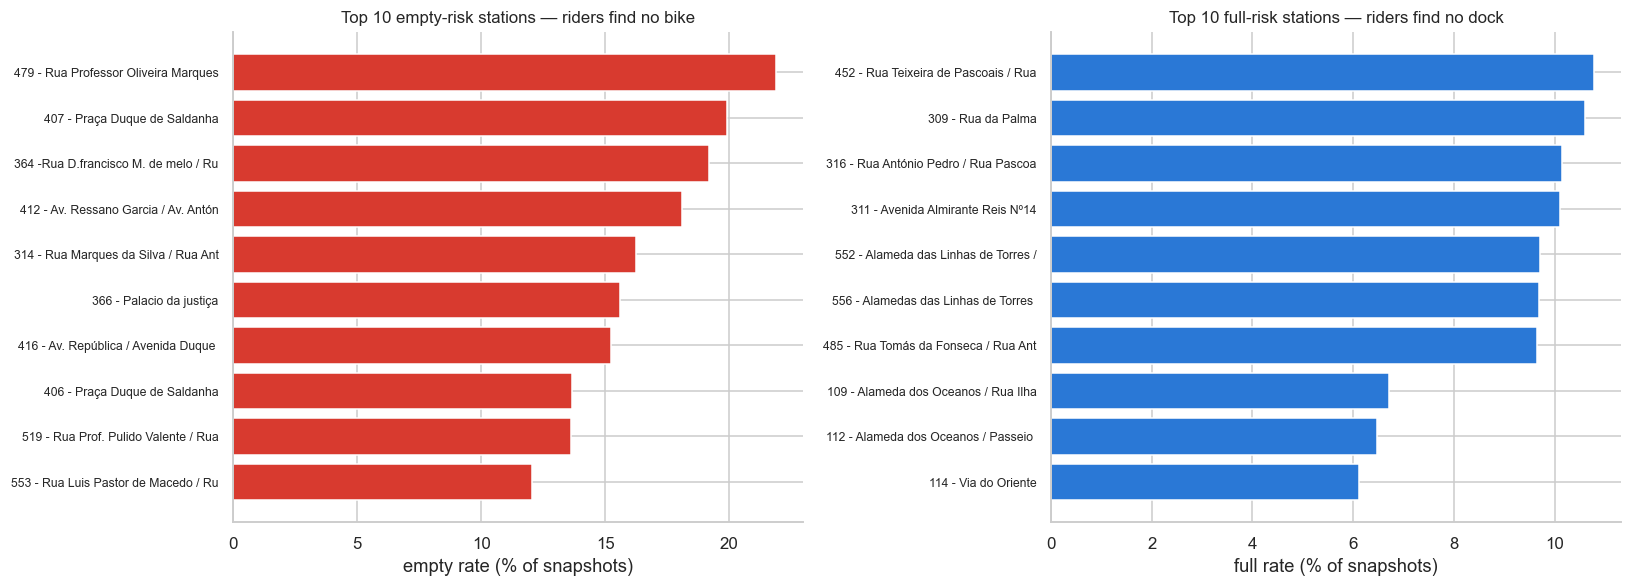

In [16]:
prof = station[station['reliable']].copy()

# nlargest picks the worst 10; sort_values then puts the worst at the TOP of a barh
# (barh draws the first row at the bottom, so ascending order reads correctly).
top_e = prof.nlargest(10, 'empty_rate').sort_values('empty_rate')
top_f = prof.nlargest(10, 'full_rate').sort_values('full_rate')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
# Horizontal bars because station names are long and would never fit on an x-axis
axes[0].barh(top_e['name'].str[:36], top_e['empty_rate'], color='#d83a2f')   # names truncated to 36 chars
axes[0].set_title('Top 10 empty-risk stations — riders find no bike',
                  fontsize=11, weight='medium')
axes[0].set_xlabel('empty rate (% of snapshots)')

axes[1].barh(top_f['name'].str[:36], top_f['full_rate'], color='#2a78d6')
axes[1].set_title('Top 10 full-risk stations — riders find no dock',
                  fontsize=11, weight='medium')
axes[1].set_xlabel('full rate (% of snapshots)')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)   # small labels so the long names fit

plt.tight_layout()
plt.show()

Stations with enough data in BOTH Q1 2020 and Q1 2023: 81
Stations only in 2023 (the expansion): 59

Spearman rank correlation of failure rate, 2020 vs 2023: 0.388
Top-10 worst stations still in the top 10 three years later: 4 of 10

Mean failure rate — Q1 2020: 5.56%   Q1 2023: 5.05%


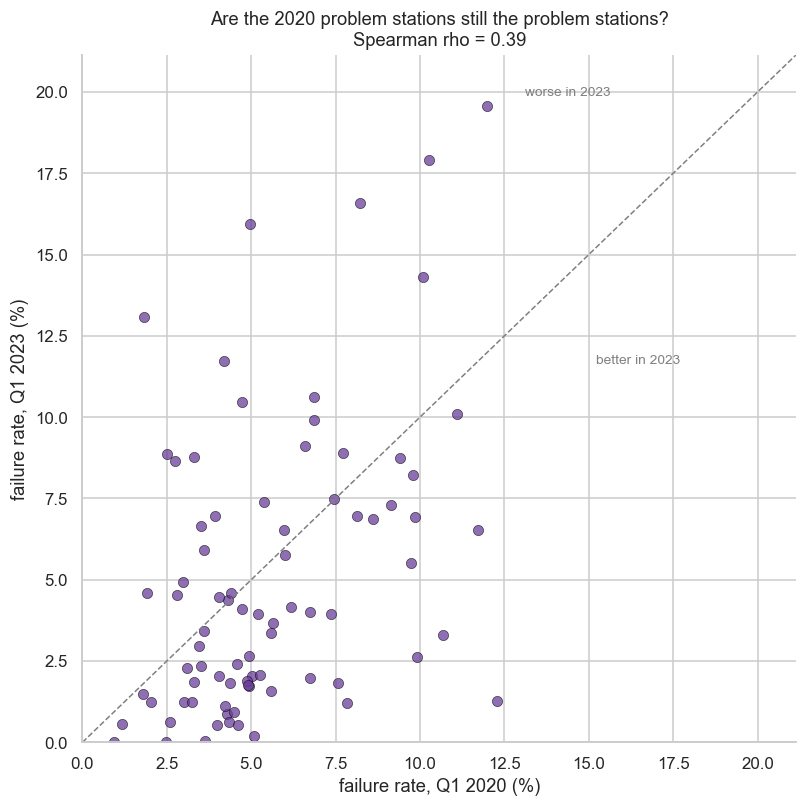

In [17]:
# Matched-quarter comparison: Q1 2020 vs Q1 2023
# Q1 only, because 2023 stops in March — comparing a full 2020 against a quarter of
# 2023 would compare seasons, not years.
q1 = base[base['quarter'] == 1]

def q1_profile(y, min_obs=500):
    """Failure rates per station for the Q1 of one year, thin stations dropped."""
    d = (q1[q1['year'] == y].groupby('station_id', observed=True)
           .agg(name=('desigcomercial', 'first'),
                n=('is_empty', 'size'),
                empty_rate=('is_empty', 'mean'),
                full_rate=('is_full', 'mean'))
           .reset_index())
    d[['empty_rate', 'full_rate']] *= 100
    d['failure_rate'] = d['empty_rate'] + d['full_rate']
    return d[d['n'] >= min_obs]   # lower bar than MIN_OBS: one quarter has fewer snapshots

p20, p23 = q1_profile(2020), q1_profile(2023)
# Inner join: only stations present in BOTH quarters can be compared over time
cmp = p20.merge(p23, on='station_id', suffixes=('_2020', '_2023'))

print(f"Stations with enough data in BOTH Q1 2020 and Q1 2023: {len(cmp)}")
print(f"Stations only in 2023 (the expansion): {len(p23) - len(cmp)}")

# Spearman, not Pearson: the question is whether the RANKING persists, and rank
# correlation is not thrown off by one extreme station.
rho = cmp['failure_rate_2020'].corr(cmp['failure_rate_2023'], method='spearman')
t20 = set(cmp.nlargest(10, 'failure_rate_2020')['station_id'])   # worst 10 in 2020
t23 = set(cmp.nlargest(10, 'failure_rate_2023')['station_id'])   # worst 10 in 2023

print(f"\nSpearman rank correlation of failure rate, 2020 vs 2023: {rho:.3f}")
print(f"Top-10 worst stations still in the top 10 three years later: {len(t20 & t23)} of 10")  # set overlap
print(f"\nMean failure rate — Q1 2020: {cmp['failure_rate_2020'].mean():.2f}%"
      f"   Q1 2023: {cmp['failure_rate_2023'].mean():.2f}%")

# Scatter with a 45-degree reference line: above it = worse in 2023, below = improved
fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.scatter(cmp['failure_rate_2020'], cmp['failure_rate_2023'], s=45, alpha=0.75,
           color='#6a3d9a', edgecolor='black', linewidth=0.4)
lim = max(cmp['failure_rate_2020'].max(), cmp['failure_rate_2023'].max()) * 1.08
ax.plot([0, lim], [0, lim], ls='--', color='gray', lw=1)     # the no-change diagonal
ax.text(lim*0.62, lim*0.94, 'worse in 2023', fontsize=9, color='gray')
ax.text(lim*0.72, lim*0.55, 'better in 2023', fontsize=9, color='gray')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)     # identical axes, or the diagonal lies
ax.set_xlabel('failure rate, Q1 2020 (%)')
ax.set_ylabel('failure rate, Q1 2023 (%)')
ax.set_title(f'Are the 2020 problem stations still the problem stations?\n'
             f'Spearman rho = {rho:.2f}', fontsize=12, weight='medium')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [18]:
# Batch coordinates (max 100 per call), preserving station order
# Elevation is not in the source files, so it is fetched once from Open-Meteo and
# merged in. External data, therefore stated as a source in the report.
coords = station[['station_id', 'lat', 'lon']].copy()

def fetch_elevation(df, chunk=100):
    """Query the API in chunks of 100 coordinate pairs, returning one elevation per row."""
    elevations = []
    for i in range(0, len(df), chunk):
        part = df.iloc[i:i+chunk]
        # The endpoint takes comma-separated lat and lon lists of equal length
        lats = ",".join(part['lat'].round(6).astype(str))
        lons = ",".join(part['lon'].round(6).astype(str))
        url = f"https://api.open-meteo.com/v1/elevation?latitude={lats}&longitude={lons}"
        r = requests.get(url, timeout=30)
        r.raise_for_status()          # fail loudly rather than storing a silent error page
        elevations.extend(r.json()['elevation'])   # extend keeps the original row order
        time.sleep(1)   # be polite between calls
    return elevations

coords['elevation'] = fetch_elevation(coords)
# Confirm nothing came back missing before this is merged into the analysis
print(f"Fetched elevation for {coords['elevation'].notna().sum()} / {len(coords)} stations")
print(coords['elevation'].describe())

Fetched elevation for 147 / 147 stations
count    147.000000
mean      64.102041
std       35.124190
min        3.000000
25%       31.500000
50%       79.000000
75%       88.500000
max      120.000000
Name: elevation, dtype: float64


In [19]:
# Merge elevation into the station profile
# left join on station_id: every station keeps its row even if a lookup had failed
station = station.merge(coords[['station_id', 'elevation']], on='station_id', how='left')

# Re-run the hills test with REAL elevation (trustworthy stations only)
prof = station[station['reliable']].copy()

print("=== HILLS HYPOTHESIS: tilt vs elevation ===")
print(f"Correlation (tilt vs elevation): {prof['tilt'].corr(prof['elevation']):.3f}")
# corr_lat comes from the latitude cell above: the two numbers side by side are the finding
print(f"  (compare: tilt vs latitude was {corr_lat:.3f})")

# The same result expressed as medians, which is easier to say out loud than a coefficient
print(f"\nMedian elevation by dominant failure type:")
print(prof.groupby('dominant')['elevation'].median())

print(f"\nEmpty-prone median elevation: {prof[prof['dominant']=='empty']['elevation'].median():.0f} m")
print(f"Full-prone  median elevation: {prof[prof['dominant']=='full']['elevation'].median():.0f} m")

# Also: correlation of raw empty_rate and full_rate with elevation
# Opposite signs are the point: height drives bikes away and pulls them down to the river.
print(f"\nempty_rate vs elevation: {prof['empty_rate'].corr(prof['elevation']):.3f}")
print(f"full_rate  vs elevation: {prof['full_rate'].corr(prof['elevation']):.3f}")

=== HILLS HYPOTHESIS: tilt vs elevation ===
Correlation (tilt vs elevation): 0.386
  (compare: tilt vs latitude was 0.061)

Median elevation by dominant failure type:
dominant
empty    81.0
full     29.5
Name: elevation, dtype: float64

Empty-prone median elevation: 81 m
Full-prone  median elevation: 30 m

empty_rate vs elevation: 0.365
full_rate  vs elevation: -0.176


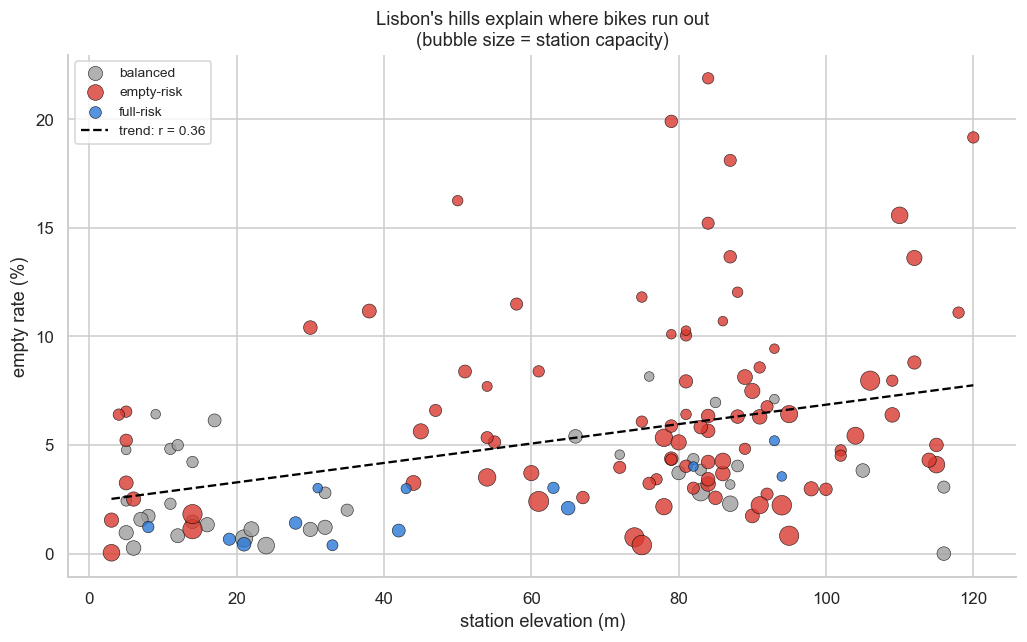

Pearson r (elevation vs empty rate): 0.365
Every +10 m of elevation is worth roughly +0.45 percentage points of empty rate.


In [20]:
prof = station[station['reliable']].copy()
x, y = prof['elevation'], prof['empty_rate']
r = x.corr(y)                              # Pearson r, quoted in the legend and the caption
slope, intercept = np.polyfit(x, y, 1)     # degree-1 fit: the straight trend line

fig, ax = plt.subplots(figsize=(9.5, 6))
type_colors = {'empty-risk': '#d83a2f', 'full-risk': '#2a78d6', 'balanced': '#9e9e9e'}
# One scatter call per failure type, so each gets its own colour and legend entry
for t, g in prof.groupby('failure_type'):
    ax.scatter(g['elevation'], g['empty_rate'], s=g['capacity'] * 4,   # bubble area = docks
               color=type_colors[t], alpha=0.8,
               edgecolor='black', linewidth=0.4, label=t)

# Draw the fitted line across the observed elevation range only, never extrapolated
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, slope * xs + intercept, color='black', lw=1.5, ls='--',
        label=f'trend: r = {r:.2f}')

ax.set_xlabel('station elevation (m)')
ax.set_ylabel('empty rate (%)')
ax.set_title("Lisbon's hills explain where bikes run out\n"
             "(bubble size = station capacity)", fontsize=12, weight='medium')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Pearson r (elevation vs empty rate): {r:.3f}")
# The slope turned into a sentence a manager can act on
print(f"Every +10 m of elevation is worth roughly "
      f"{slope*10:+.2f} percentage points of empty rate.")

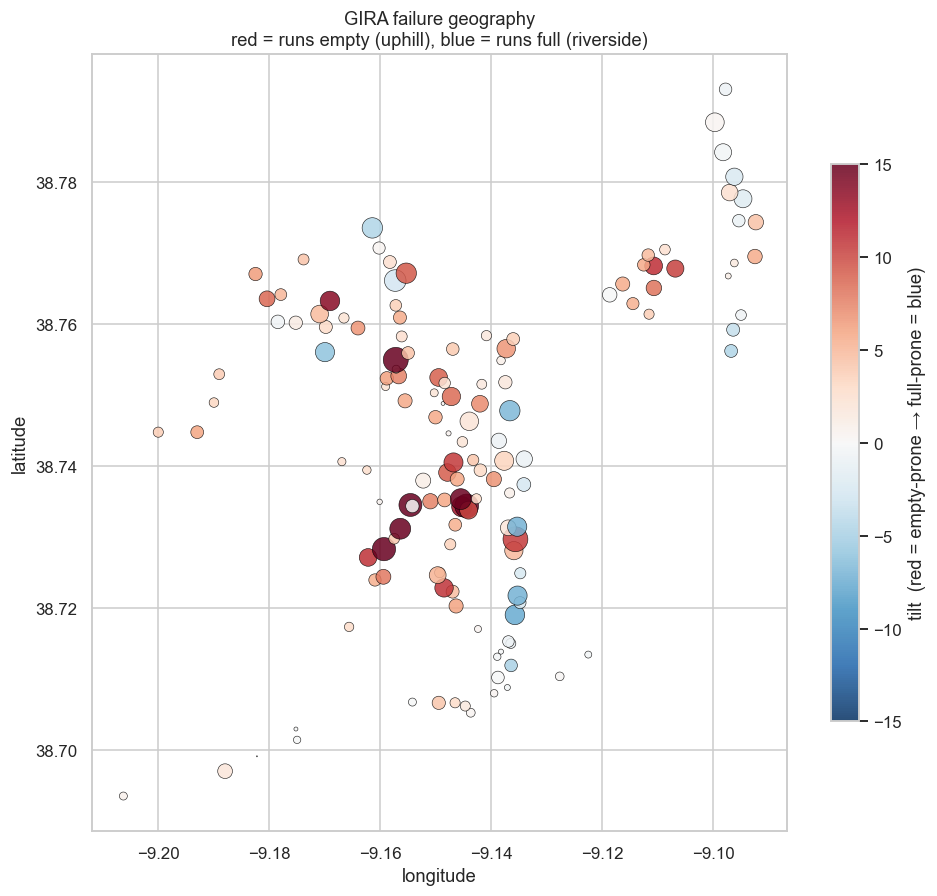

In [21]:
prof = station[station['reliable']].copy()
prof['total_fail'] = prof['empty_rate'] + prof['full_rate']

fig, ax = plt.subplots(figsize=(9, 9))

# A map drawn from raw coordinates: x = longitude, y = latitude.
# diverging color: red = empty-prone (uphill), blue = full-prone (riverside)
sc = ax.scatter(prof['lon'], prof['lat'],
                c=prof['tilt'], cmap='RdBu_r',   # colour = which way the station leans
                s=prof['total_fail'] * 12,      # size = severity
                vmin=-15, vmax=15,               # symmetric so white = balanced
                edgecolor='black', linewidth=0.4, alpha=0.85)

cbar = plt.colorbar(sc, shrink=0.6, label='tilt  (red = empty-prone → full-prone = blue)')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.set_title('GIRA failure geography\nred = runs empty (uphill), blue = runs full (riverside)',
             fontsize=12, weight='medium')
ax.set_aspect(1.28)   # rough lat/lon aspect correction for Lisbon's latitude
plt.tight_layout()
plt.show()

In [22]:
prof = station[station['reliable']].copy()
prof['total_fail'] = prof['empty_rate'] + prof['full_rate']

# center on Lisbon
# Same information as the scatter above, but on a real basemap and clickable.
m = folium.Map(location=[38.725, -9.150], zoom_start=13, tiles='CartoDB positron')

# diverging color scale: blue (full-prone) -> white -> red (empty-prone)
cmap = LinearColormap(['#2a78d6', '#f7f7f7', '#d83a2f'],
                      vmin=-15, vmax=15, caption='tilt: blue = full-prone, red = empty-prone')

# One circle per station; folium has no vectorised API, so this loops row by row
for _, r in prof.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=3 + r['total_fail'] * 0.6,          # size = severity
        color='black', weight=0.5,
        fill=True, fill_color=cmap(r['tilt']), fill_opacity=0.85,
        popup=folium.Popup(                        # the detail panel on click
            f"<b>{r['name']}</b><br>"
            f"elevation: {r['elevation']:.0f} m<br>"
            f"empty: {r['empty_rate']:.1f}%  |  full: {r['full_rate']:.1f}%<br>"
            f"dominant: {r['dominant']}", max_width=260)
    ).add_to(m)

cmap.add_to(m)                     # attach the legend to the map
m.save('gira_failure_map.html')    # standalone file, shareable without the notebook
m   # displays inline in the notebook

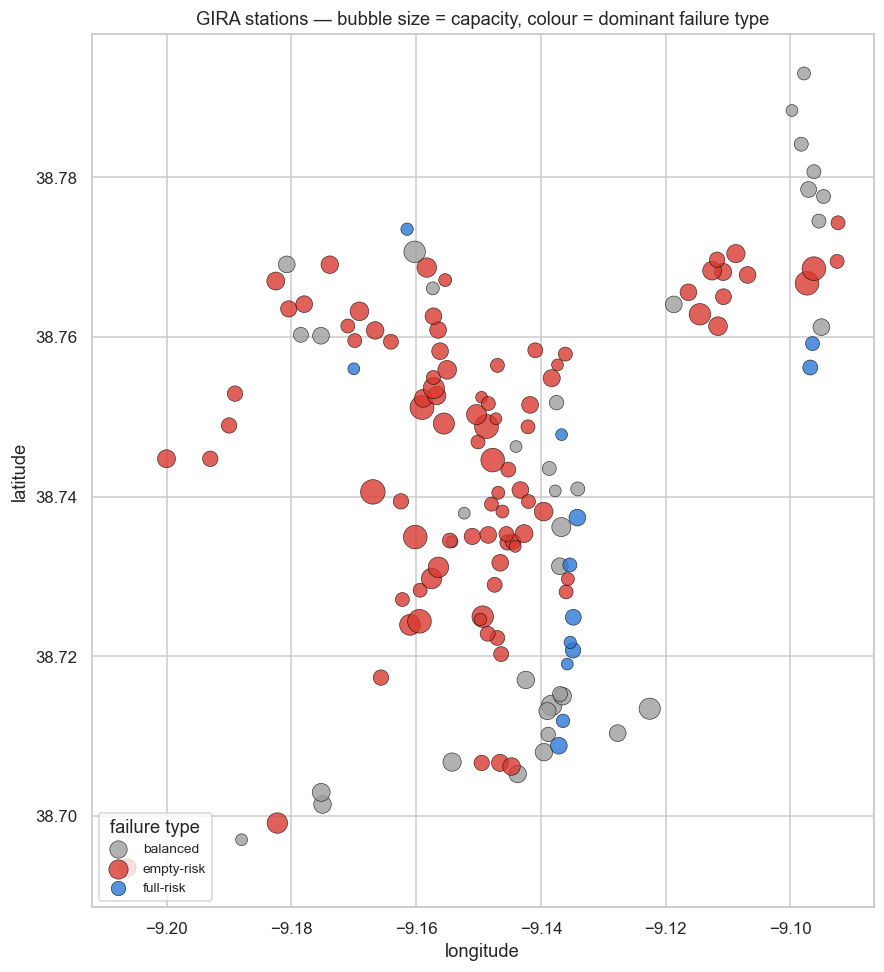

Major transit-hub stations:
                                           name  capacity  elevation  empty_rate  full_rate failure_type
                          104 - Gare do Oriente      40.0       14.0        1.13       0.14   empty-risk
                           114 - Via do Oriente      10.0        9.0        6.42       6.11     balanced
213 - Av. Infante Dom Henrique / Santa Apolónia      32.0       21.0        0.70       1.05     balanced
                            218 - Cais do Sodré      22.0        6.0        2.51       1.10   empty-risk
                  406 - Praça Duque de Saldanha      17.0       87.0       13.67       0.96   empty-risk
                  407 - Praça Duque de Saldanha      17.0       79.0       19.90       0.25   empty-risk
                  408 - Praça Duque de Saldanha      10.0       86.0       10.70       0.70   empty-risk
    446 - Av. República / Interface Entrecampos      40.0       74.0        0.75       0.21   empty-risk
     456 - Entrecampos / Av

In [23]:
prof = station[station['reliable']].copy()
type_colors = {'empty-risk': '#d83a2f', 'full-risk': '#2a78d6', 'balanced': '#9e9e9e'}

fig, ax = plt.subplots(figsize=(9.5, 9))
# The encoding the brief specifies: size = capacity, colour = three-way failure type
for t, g in prof.groupby('failure_type'):
    ax.scatter(g['lon'], g['lat'], s=g['capacity'] * 6,
               color=type_colors[t], alpha=0.8,
               edgecolor='black', linewidth=0.4, label=t)

ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
ax.set_title('GIRA stations — bubble size = capacity, colour = dominant failure type',
             fontsize=12, weight='medium')
ax.legend(title='failure type', fontsize=9, loc='lower left')
ax.set_aspect(1.28)   # same lat/lon correction as the map above
plt.tight_layout()
plt.show()

# The transit hubs the brief singles out — are they a group of their own?
# Matched on name, with spelling variants and unaccented forms in the pattern.
HUBS = 'Oriente|Entrecampos|Cais do Sodré|Sodre|Saldanha|Santa Apolónia|Apolonia'
hubs = prof[prof['name'].str.contains(HUBS, case=False, na=False)]
print("Major transit-hub stations:")
print(hubs[['name','capacity','elevation','empty_rate','full_rate','failure_type']]
      .round(2).to_string(index=False))
# Hub averages against network averages: the comparison is the answer
print(f"\nHub mean failure rate:      {hubs['total_fail'].mean():.2f}%")
print(f"Network mean failure rate:  {prof['total_fail'].mean():.2f}%")
print(f"Hub mean capacity:          {hubs['capacity'].mean():.1f} docks "
      f"(network: {prof['capacity'].mean():.1f})")

## Step 7 - what to do

In [24]:
# Station × hour failure rates, on `base` (repair + impossible out of the denominator)
# This grid is the unit of every recommendation below: not "which station" but
# "which station, at which hour", because that is what a rebalancing van is dispatched to.
sh = (base.groupby(['station_id', 'hour'], observed=True)
          .agg(empty_rate=('is_empty', 'mean'),
               full_rate=('is_full', 'mean'),
               n=('is_empty', 'size'))
          .reset_index())
sh['empty_rate'] *= 100
sh['full_rate']  *= 100
sh['failure_rate'] = sh['empty_rate'] + sh['full_rate']

# keep only station-hours with enough observations to trust
# (the same logic as MIN_OBS, at the finer station-hour grain)
sh = sh[sh['n'] >= 30]

# attach station attributes for context and for the maps further down
sh = sh.merge(station[['station_id', 'name', 'elevation', 'failure_type',
                       'dominant', 'lat', 'lon', 'capacity']],
              on='station_id', how='left')

print("Station-hour cells:", len(sh))
print("\nWorst empty station-hours (need bikes DELIVERED):")
print(sh.nlargest(8, 'empty_rate')[['name','hour','empty_rate','elevation']].to_string(index=False))
print("\nWorst full station-hours (need bikes REMOVED):")
print(sh.nlargest(8, 'full_rate')[['name','hour','full_rate','elevation']].to_string(index=False))

Station-hour cells: 3384

Worst empty station-hours (need bikes DELIVERED):
                                          name  hour  empty_rate  elevation
314 - Rua Marques da Silva / Rua António Pedro    12   40.469208       50.0
314 - Rua Marques da Silva / Rua António Pedro    11   37.704918       50.0
          479 - Rua Professor Oliveira Marques     2   36.145648       84.0
          479 - Rua Professor Oliveira Marques     4   35.969388       84.0
          479 - Rua Professor Oliveira Marques     1   35.714286       84.0
          479 - Rua Professor Oliveira Marques     3   35.530822       84.0
          479 - Rua Professor Oliveira Marques    23   35.405405       84.0
          479 - Rua Professor Oliveira Marques     5   35.361552       84.0

Worst full station-hours (need bikes REMOVED):
                                                name  hour  full_rate  elevation
       316 - Rua António Pedro / Rua Pascoal de Melo     4  32.998565       63.0
       316 - Rua António Pedro

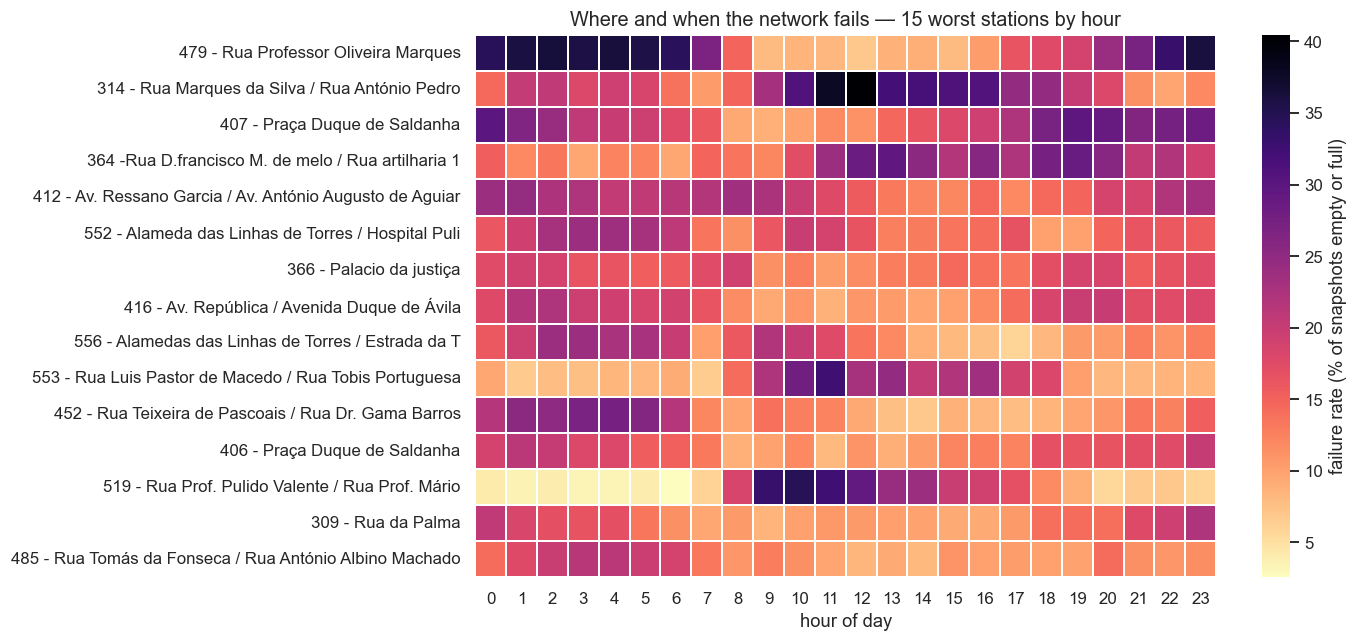

In [25]:
# Overall failure rate per station, weighted by snapshot count (never a plain mean of rates)
# Averaging 24 hourly rates would treat 03:00 (few snapshots) as equal to 18:00.
# Weighting by n reconstructs the true station-level rate.
sh['_w'] = sh['failure_rate'] * sh['n']                       # numerator: failures per hour
overall = sh.groupby('station_id', observed=True)[['_w', 'n']].sum()
overall['failure_rate'] = overall['_w'] / overall['n']        # divide by total snapshots
worst15 = overall.nlargest(15, 'failure_rate').index

# Reshape to stations x hours: rows become the heatmap's y-axis, hours its x-axis
heat_raw = (sh[sh['station_id'].isin(worst15)]
            .pivot_table(index='name', columns='hour', values='failure_rate',
                         fill_value=0, observed=True))
# Sort rows worst-first so the eye starts at the top of the priority list
heat_raw = heat_raw.loc[heat_raw.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heat_raw, cmap='magma_r', ax=ax,
            cbar_kws={'label': 'failure rate (% of snapshots empty or full)'},
            linewidths=0.3, linecolor='white')   # thin gridlines separate the cells
ax.set_title('Where and when the network fails — 15 worst stations by hour',
             fontsize=13, weight='medium')
ax.set_xlabel('hour of day'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [26]:
# ASSUMPTION (not derived from this dataset): relative rider activity by hour, 0..1.
# Shape chosen to match the commuting pattern the hourly analysis in Step 5 already
# showed: low overnight, morning peak 8-9, evening peak 17-19. Sensitivity note: the
# top of the priority list is stable for any curve that peaks at the commute hours.
demand_curve = {
    0: 0.10, 1: 0.05, 2: 0.03, 3: 0.02, 4: 0.02, 5: 0.05,
    6: 0.20, 7: 0.55, 8: 0.95, 9: 0.85, 10: 0.55, 11: 0.55,
    12: 0.60, 13: 0.60, 14: 0.55, 15: 0.55, 16: 0.70, 17: 0.95,
    18: 1.00, 19: 0.85, 20: 0.55, 21: 0.40, 22: 0.28, 23: 0.18
}
# Turned into a Series named by hour, so it can be merged onto the station-hour grid
demand_weight = pd.Series(demand_curve, name='demand_weight')
demand_weight.index.name = 'hour'

print("Demand weight by hour:")
print(demand_weight.to_string())

Demand weight by hour:
hour
0     0.10
1     0.05
2     0.03
3     0.02
4     0.02
5     0.05
6     0.20
7     0.55
8     0.95
9     0.85
10    0.55
11    0.55
12    0.60
13    0.60
14    0.55
15    0.55
16    0.70
17    0.95
18    1.00
19    0.85
20    0.55
21    0.40
22    0.28
23    0.18


In [27]:
# Merge the demand weight onto the station-hour grid and compute priority
# Joins on `hour`, so every station in a given hour gets the same weight
sh = sh.merge(demand_weight, on='hour', how='left')

# Priority = failure severity × how much riders need bikes then.
# Split by direction: empty-priority (needs bikes delivered) vs full-priority (needs removal)
# Kept as two columns because the two problems need opposite van movements.
sh['empty_priority'] = sh['empty_rate'] * sh['demand_weight']
sh['full_priority']  = sh['full_rate']  * sh['demand_weight']

print("Top 10 DELIVER-bikes priorities (empty × demand):")
print(sh.nlargest(10, 'empty_priority')
        [['name','hour','empty_rate','demand_weight','empty_priority','elevation']]
        .round(2).to_string(index=False))
print("\nTop 10 REMOVE-bikes priorities (full × demand):")
print(sh.nlargest(10, 'full_priority')
        [['name','hour','full_rate','demand_weight','full_priority','elevation']]
        .round(2).to_string(index=False))

Top 10 DELIVER-bikes priorities (empty × demand):
                                                    name  hour  empty_rate  demand_weight  empty_priority  elevation
        519 - Rua Prof. Pulido Valente / Rua Prof. Mário     9       33.33           0.85           28.33      112.0
      364 -Rua D.francisco M. de melo / Rua artilharia 1    18       27.36           1.00           27.36      120.0
                           407 - Praça Duque de Saldanha    18       26.96           1.00           26.96       79.0
                           407 - Praça Duque de Saldanha    19       29.35           0.85           24.95       79.0
          314 - Rua Marques da Silva / Rua António Pedro    18       24.75           1.00           24.75       50.0
      364 -Rua D.francisco M. de melo / Rua artilharia 1    19       28.74           0.85           24.43      120.0
          314 - Rua Marques da Silva / Rua António Pedro    12       40.47           0.60           24.28       50.0
          314 

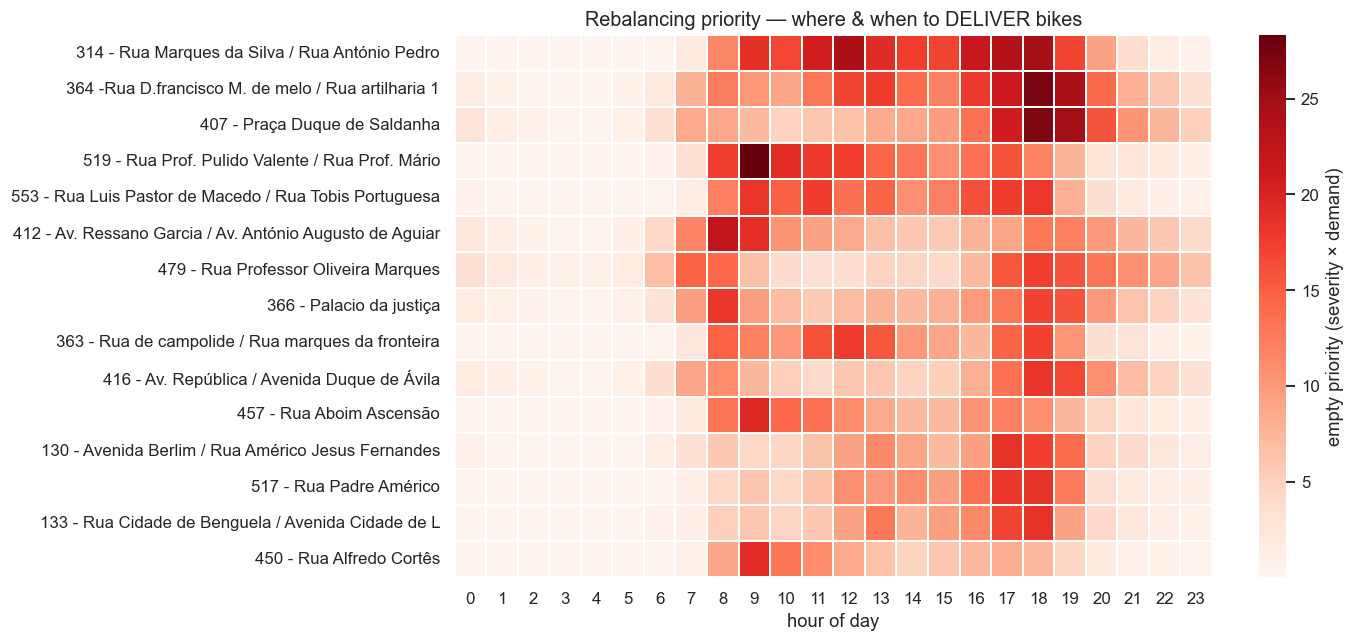

In [28]:
# Rank stations by their single worst hour, not their average: a station that is
# catastrophic at 08:00 and fine otherwise still needs a van at 08:00.
top_empty_stations = (sh.groupby('station_id', observed=True)['empty_priority'].max()
                        .nlargest(15).index)

# Long grid -> wide matrix, one row per station, one column per hour
heat = (sh[sh['station_id'].isin(top_empty_stations)]
        .pivot_table(index='name', columns='hour', values='empty_priority',
                     fill_value=0, observed=True))          # <- silences the warning

heat = heat.loc[heat.sum(axis=1).sort_values(ascending=False).index]   # worst station on top

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heat, cmap='Reds', ax=ax,           # red = the empty/deliver direction
            cbar_kws={'label': 'empty priority (severity × demand)'},
            linewidths=0.3, linecolor='white')
ax.set_title('Rebalancing priority — where & when to DELIVER bikes',
             fontsize=13, weight='medium')
ax.set_xlabel('hour of day'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

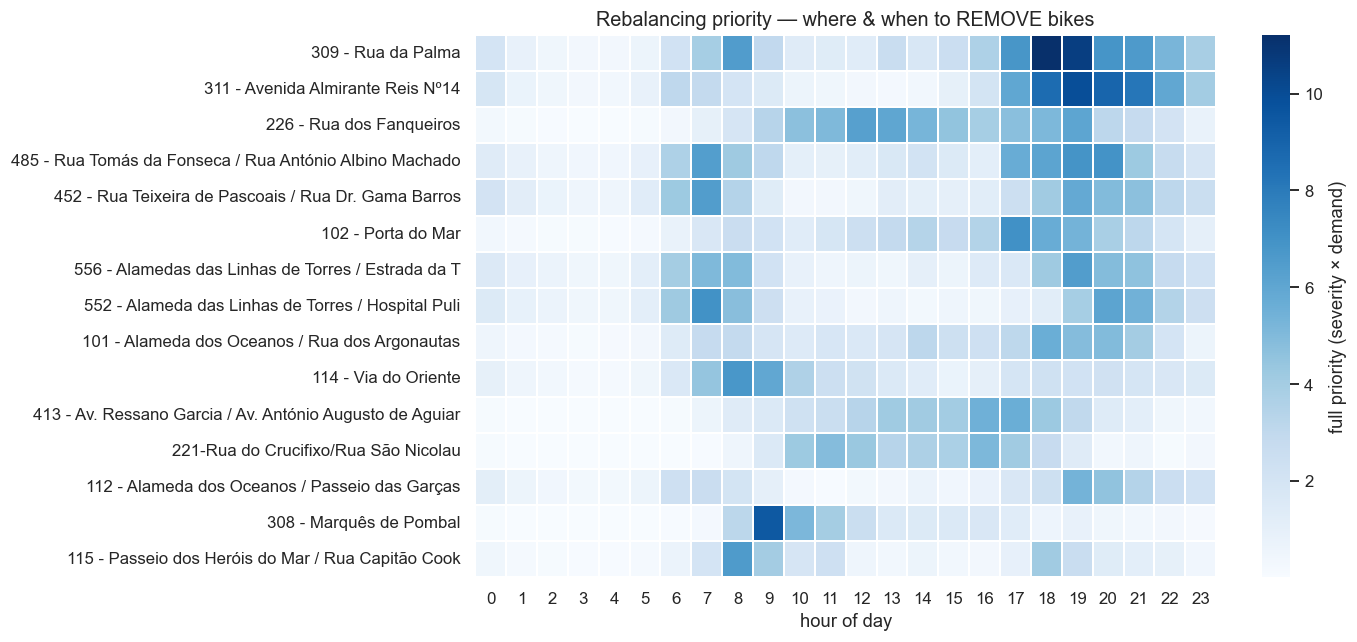

In [29]:
# Mirror image of the cell above, for the opposite failure: stations that fill up
top_full_stations = (sh.groupby('station_id', observed=True)['full_priority'].max()
                       .nlargest(15).index)

heatf = (sh[sh['station_id'].isin(top_full_stations)]
         .pivot_table(index='name', columns='hour', values='full_priority',
                      fill_value=0, observed=True))
heatf = heatf.loc[heatf.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heatf, cmap='Blues', ax=ax,         # blue = the full/collect direction
            cbar_kws={'label': 'full priority (severity × demand)'},
            linewidths=0.3, linecolor='white')
ax.set_title('Rebalancing priority — where & when to REMOVE bikes',
             fontsize=13, weight='medium')
ax.set_xlabel('hour of day'); ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [30]:
# Build a unified action list from the worst station-hours of each type
R_EARTH = 6371.0   # km, mean Earth radius used by the haversine formula

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km; lat2/lon2 may be arrays."""
    # Straight-line lat/lon differences are not distances: a degree of longitude is
    # shorter than a degree of latitude, and more so the further from the equator.
    p1, p2 = np.radians(lat1), np.radians(lat2)   # trig functions need radians
    dphi   = p2 - p1                              # latitude difference
    dlam   = np.radians(lon2 - lon1)              # longitude difference
    a = np.sin(dphi/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dlam/2)**2
    return 2 * R_EARTH * np.arcsin(np.sqrt(a))    # arrays in, array of km out

# Columns both halves of the action list share
KEEP = ['station_id','name','hour','demand_weight','elevation','lat','lon']

# The 15 worst empty station-hours become DELIVER jobs...
deliver = (sh.nlargest(15, 'empty_priority')[KEEP + ['empty_rate','empty_priority']]
             .rename(columns={'empty_rate':'fail_rate','empty_priority':'priority'}))
deliver['action'] = 'DELIVER bikes to'

# ...and the 15 worst full station-hours become COLLECT jobs.
# Both are renamed to the same column names so they can be stacked.
collect = (sh.nlargest(15, 'full_priority')[KEEP + ['full_rate','full_priority']]
             .rename(columns={'full_rate':'fail_rate','full_priority':'priority'}))
collect['action'] = 'COLLECT bikes from'

# One list, sorted by priority: this is the operational deliverable
actions = pd.concat([deliver, collect], ignore_index=True)
actions = actions.sort_values('priority', ascending=False).reset_index(drop=True)

# tidy display
actions['when'] = actions['hour'].apply(lambda h: f"{h:02d}:00")   # 8 -> "08:00"
out = actions[['action','name','when','fail_rate','elevation','priority']].round(1)
print("=== GIRA REBALANCING PRIORITY LIST (demand-weighted) ===\n")
print(out.head(20).to_string(index=False))

=== GIRA REBALANCING PRIORITY LIST (demand-weighted) ===

            action                                                     name  when  fail_rate  elevation  priority
  DELIVER bikes to         519 - Rua Prof. Pulido Valente / Rua Prof. Mário 09:00       33.3      112.0      28.3
  DELIVER bikes to       364 -Rua D.francisco M. de melo / Rua artilharia 1 18:00       27.4      120.0      27.4
  DELIVER bikes to                            407 - Praça Duque de Saldanha 18:00       27.0       79.0      27.0
  DELIVER bikes to                            407 - Praça Duque de Saldanha 19:00       29.4       79.0      24.9
  DELIVER bikes to           314 - Rua Marques da Silva / Rua António Pedro 18:00       24.7       50.0      24.7
  DELIVER bikes to       364 -Rua D.francisco M. de melo / Rua artilharia 1 19:00       28.7      120.0      24.4
  DELIVER bikes to           314 - Rua Marques da Silva / Rua António Pedro 12:00       40.5       50.0      24.3
  DELIVER bikes to           3

In [31]:
# Pair collect-jobs with deliver-jobs inside a time window.
# Each source station is used ONCE, and the partner is chosen by real distance
# (haversine_km is defined in the cell above).
def routes_for_window(hours, label, max_routes=4):
    # Both job lists, restricted to this window and de-duplicated: a station appearing
    # at 17:00 and 18:00 is still one station and should only be visited once.
    d = (actions[(actions['action'] == 'DELIVER bikes to') & (actions['hour'].isin(hours))]
         .drop_duplicates('station_id').sort_values('priority', ascending=False))
    c = (actions[(actions['action'] == 'COLLECT bikes from') & (actions['hour'].isin(hours))]
         .drop_duplicates('station_id').sort_values('priority', ascending=False))

    print(f"\n=== {label} (hours {hours[0]:02d}–{hours[-1]:02d}) ===")
    if d.empty or c.empty:        # no pairing is possible with only one job type
        print("  no jobs of one type in this window")
        return

    used = set()                  # source stations already assigned to a route
    # Greedy matching: take the most urgent delivery first and give it the nearest
    # unused source. Not globally optimal, but defensible and easy to explain.
    for _, dj in d.head(max_routes).iterrows():
        pool = c[~c['station_id'].isin(used)]
        if pool.empty:
            print("  (no unused collect station left — the network is short of full stations)")
            break
        # Distance from this delivery target to every remaining source at once
        dist = haversine_km(dj['lat'], dj['lon'], pool['lat'].values, pool['lon'].values)
        cj = pool.iloc[int(np.argmin(dist))]   # argmin gives the position of the nearest
        used.add(cj['station_id'])             # mark it so no other route reuses it
        km = dist.min()
        print(f"  COLLECT from {cj['name'][:38]:38} ({cj['elevation']:.0f}m, {cj['fail_rate']:.0f}% full)")
        print(f"  → DELIVER to {dj['name'][:38]:38} ({dj['elevation']:.0f}m, {dj['fail_rate']:.0f}% empty)")
        # Positive climb = the van does the uphill work instead of the rider
        print(f"     {km:.2f} km, climb {dj['elevation']-cj['elevation']:+.0f} m\n")

routes_for_window([17, 18, 19, 20], "EVENING PEAK ROUTES")
routes_for_window([7, 8, 9],        "MORNING PEAK ROUTES")


=== EVENING PEAK ROUTES (hours 17–20) ===
  COLLECT from 311 - Avenida Almirante Reis Nº14      (43m, 12% full)
  → DELIVER to 364 -Rua D.francisco M. de melo / Rua  (120m, 27% empty)
     2.21 km, climb +77 m

  COLLECT from 309 - Rua da Palma                     (31m, 11% full)
  → DELIVER to 407 - Praça Duque de Saldanha          (79m, 27% empty)
     1.86 km, climb +48 m

  COLLECT from 485 - Rua Tomás da Fonseca / Rua Antón (94m, 13% full)
  → DELIVER to 314 - Rua Marques da Silva / Rua Antón (50m, 25% empty)
     4.18 km, climb -44 m


=== MORNING PEAK ROUTES (hours 07–09) ===
  COLLECT from 552 - Alameda das Linhas de Torres / H (85m, 13% full)
  → DELIVER to 519 - Rua Prof. Pulido Valente / Rua P (112m, 33% empty)
     1.07 km, climb +27 m

  COLLECT from 308 - Marquês de Pombal                (54m, 11% full)
  → DELIVER to 412 - Av. Ressano Garcia / Av. António (87m, 23% empty)
     1.18 km, climb +33 m

  COLLECT from 114 - Via do Oriente                   (9m, 7% full)
  → 

## Step 8 — rebalancing problem or sizing problem?

In [32]:
# (a) How far is each empty-risk station from its nearest full-risk neighbour?
# Short hops = a rebalancing problem, solvable with a van. Long hops = a sizing and
# coverage problem, which no amount of driving fixes.
prof = station[station['reliable']].copy()

# haversine_km was defined in the priority-list cell above.

# The two opposite populations, using the three-way classification
e_st = prof[prof['failure_type'] == 'empty-risk']
f_st = prof[prof['failure_type'] == 'full-risk']
print(f"empty-risk stations: {len(e_st)}   full-risk stations: {len(f_st)}\n")

pairs = []
# Only the 15 worst empty-risk stations: those are the ones that would be served first
for _, e in e_st.nlargest(15, 'empty_rate').iterrows():
    d = haversine_km(e['lat'], e['lon'], f_st['lat'].values, f_st['lon'].values)
    j = int(np.argmin(d))      # index of the closest full-risk station
    nb_ = f_st.iloc[j]
    pairs.append({
        'empty_station': e['name'][:36], 'empty_rate': e['empty_rate'],
        'nearest_full':  nb_['name'][:36], 'full_rate':  nb_['full_rate'],
        'km': d[j], 'climb_m': e['elevation'] - nb_['elevation']})   # height the van gains

pairs = pd.DataFrame(pairs)
print("Worst empty-risk stations and their nearest full-risk neighbour:")
print(pairs.round(2).to_string(index=False))
# Median hop plus a count under 1 km: the headline answer to "is a van loop viable?"
print(f"\nMedian van hop: {pairs['km'].median():.2f} km  |  "
      f"within 1 km: {(pairs['km'] <= 1).sum()} of {len(pairs)}")
print("Positive climb_m = the van drives bikes uphill, which is exactly what riders refuse to do.")

empty-risk stations: 91   full-risk stations: 13

Worst empty-risk stations and their nearest full-risk neighbour:
                       empty_station  empty_rate                         nearest_full  full_rate   km  climb_m
479 - Rua Professor Oliveira Marques       21.89 485 - Rua Tomás da Fonseca / Rua Ant       9.64 1.11    -10.0
       407 - Praça Duque de Saldanha       19.90 316 - Rua António Pedro / Rua Pascoa      10.15 0.85     16.0
364 -Rua D.francisco M. de melo / Ru       19.17 316 - Rua António Pedro / Rua Pascoa      10.15 2.11     57.0
412 - Av. Ressano Garcia / Av. Antón       18.11 316 - Rua António Pedro / Rua Pascoa      10.15 1.70     24.0
314 - Rua Marques da Silva / Rua Ant       16.25 316 - Rua António Pedro / Rua Pascoa      10.15 0.20    -13.0
            366 - Palacio da justiça       15.58 316 - Rua António Pedro / Rua Pascoa      10.15 1.83     47.0
416 - Av. República / Avenida Duque        15.22 316 - Rua António Pedro / Rua Pascoa      10.15 0.98     21

Stations by first year of appearance:
first_year
2020    85
2021    18
2022    38

Mean failure rate by expansion cohort:
            mean  count
first_year             
2020        7.04     85
2021        8.16     18
2022        7.02     38


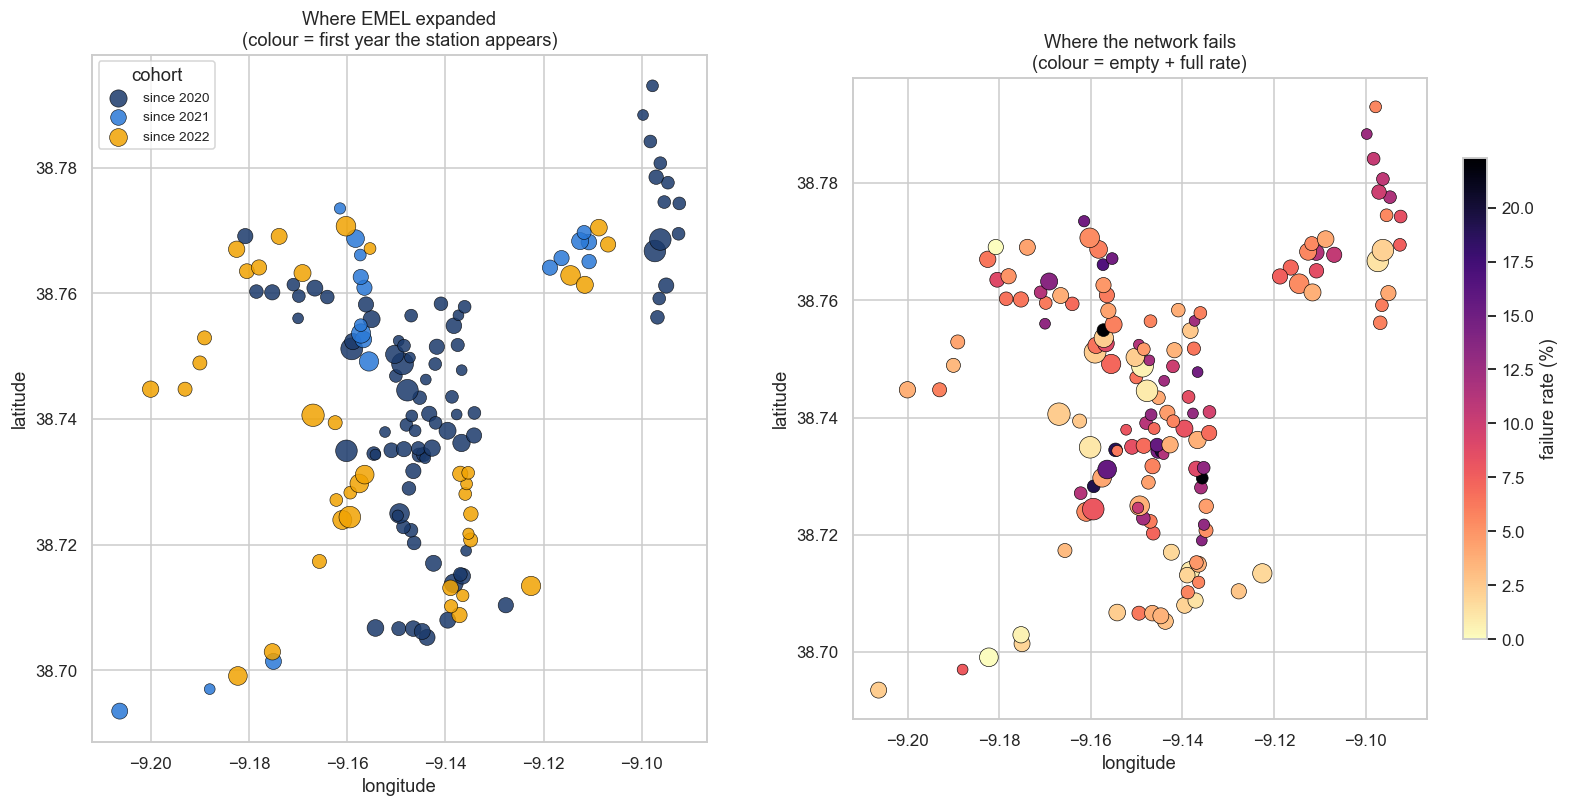

In [33]:
# (b) Where EMEL expanded vs where the network fails
# First year a station is seen in the data = its expansion cohort
first_seen = base.groupby('station_id', observed=True)['year'].min().rename('first_year')
prof = station[station['reliable']].merge(first_seen, on='station_id', how='left')

print("Stations by first year of appearance:")
print(prof['first_year'].value_counts().sort_index().to_string())
# If newer cohorts fail as much as older ones, growth is not fixing the problem
print("\nMean failure rate by expansion cohort:")
print(prof.groupby('first_year')['total_fail'].agg(['mean', 'count']).round(2))

# Two maps of the same stations, deliberately side by side: the comparison IS the answer
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
yr_colors = {2020: '#1b3a6b', 2021: '#2a78d6', 2022: '#f0a202', 2023: '#d83a2f'}

# Left: colour = when the station arrived
for yv, g in prof.groupby('first_year'):
    axes[0].scatter(g['lon'], g['lat'], s=g['capacity'] * 5,
                    color=yr_colors.get(int(yv), 'gray'), alpha=0.85,
                    edgecolor='black', linewidth=0.4, label=f'since {int(yv)}')
axes[0].set_title('Where EMEL expanded\n(colour = first year the station appears)',
                  fontsize=12, weight='medium')
axes[0].legend(fontsize=9, title='cohort')

# Right: same positions and sizes, colour = how badly the station fails
sc = axes[1].scatter(prof['lon'], prof['lat'], s=prof['capacity'] * 5,
                     c=prof['total_fail'], cmap='magma_r',
                     edgecolor='black', linewidth=0.4)
plt.colorbar(sc, ax=axes[1], shrink=0.7, label='failure rate (%)')
axes[1].set_title('Where the network fails\n(colour = empty + full rate)',
                  fontsize=12, weight='medium')

for ax in axes:
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
    ax.set_aspect(1.28)   # same lat/lon correction used on every map here

plt.tight_layout()
plt.show()

In [34]:
import os
os.makedirs('chart_data', exist_ok=True)

hourly_split.to_csv('chart_data/weekday_weekend.csv', index=False)

station[station['reliable']][['station_id','name','lat','lon','capacity',
    'empty_rate','full_rate','tilt','elevation','failure_type']].to_csv(
    'chart_data/geography.csv', index=False)

sh[['station_id','name','hour','empty_rate','full_rate','n',
    'empty_priority','full_priority']].to_csv(
    'chart_data/station_hour.csv', index=False)

print("written:", os.listdir('chart_data'))

written: ['geography.csv', 'station_hour.csv', 'weekday_weekend.csv']
